In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

In [313]:
import warnings
warnings=warnings.filterwarnings('ignore')

**Collecting Data (Step 3)**

In [314]:
# Load the Datasets
data=pd.read_csv("mcdonalds.csv")
print(f"The Shape of the Dataset is : {data.shape}")
data.head()

The Shape of the Dataset is : (1453, 15)


,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male


In [315]:
data.drop_duplicates(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1431 entries, 0 to 1452
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   yummy           1431 non-null   object
 1   convenient      1431 non-null   object
 2   spicy           1431 non-null   object
 3   fattening       1431 non-null   object
 4   greasy          1431 non-null   object
 5   fast            1431 non-null   object
 6   cheap           1431 non-null   object
 7   tasty           1431 non-null   object
 8   expensive       1431 non-null   object
 9   healthy         1431 non-null   object
 10  disgusting      1431 non-null   object
 11  Like            1431 non-null   object
 12  Age             1431 non-null   int64 
 13  VisitFrequency  1431 non-null   object
 14  Gender          1431 non-null   object
dtypes: int64(1), object(14)
memory usage: 178.9+ KB


**Exploring Data (Step 4)**

In [316]:
# Extract first 11 columns and Convert "Yes" to 1 and others to 0
df=data.iloc[:,0:11].replace("Yes",1).replace("No",0)

# Calculate column-wise mean and round to 2 decimals
mean=df.mean().round(2)
mean

,0
yummy,0.55
convenient,0.91
spicy,0.10
fattening,0.87
greasy,0.53
fast,0.90
cheap,0.60
tasty,0.64
expensive,0.36
healthy,0.20


In [317]:
# Perform PCA
pca=PCA()
pca.fit(df)

# Standard deviation of each component
pca_std=np.round(np.sqrt(pca.explained_variance_), 2)

# Proportion of Variance
pca_pv=np.round(pca.explained_variance_ratio_, 3)

# Cumulative Proportion
pca_cp=pca_pv.cumsum()

pca_df=pd.DataFrame({
    "Standard Deviation" : pca_std,
    "Proportion of Variance" : pca_pv,
    "Cumulative Proportion" : pca_cp
})
print(pca_df)

# Storing the component
component=pca.components_

# Create a DataFrame with components
print("\nPCA Components:")
component_df=pd.DataFrame(
    np.round(component, 3),
    columns=df.columns,
    index=[f"PC{i+1}" for i in range(len(component))]
).T
component_df

    Standard Deviation  Proportion of Variance  Cumulative Proportion
0                 0.76                   0.299                  0.299
1                 0.61                   0.192                  0.491
2                 0.50                   0.133                  0.624
3                 0.40                   0.083                  0.707
4                 0.34                   0.060                  0.767
5                 0.31                   0.051                  0.818
6                 0.29                   0.044                  0.862
7                 0.28                   0.040                  0.902
8                 0.27                   0.037                  0.939
9                 0.25                   0.033                  0.972
10                0.24                   0.030                  1.002

PCA Components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
yummy,0.474,-0.371,0.301,0.054,0.308,-0.170,-0.278,-0.013,-0.574,0.108,-0.043
convenient,0.155,-0.017,0.063,-0.145,-0.277,0.344,-0.060,0.108,0.016,0.652,0.561
spicy,0.007,-0.019,0.039,0.199,-0.074,0.353,0.707,-0.381,-0.396,0.079,-0.140
fattening,-0.116,0.034,0.322,-0.349,0.070,0.403,-0.392,-0.591,0.160,0.012,-0.252
greasy,-0.304,0.058,0.803,0.245,-0.363,-0.215,0.039,0.142,0.003,-0.008,-0.002
fast,0.109,0.087,0.066,-0.098,-0.113,0.599,-0.085,0.625,-0.168,-0.228,-0.342
cheap,0.341,0.607,0.156,0.123,0.127,0.101,-0.041,-0.141,-0.074,-0.442,0.477
tasty,0.469,-0.312,0.286,-0.007,0.212,0.079,0.357,0.073,0.640,-0.076,-0.022
expensive,-0.333,-0.599,-0.028,0.069,0.000,0.263,-0.068,-0.032,-0.064,-0.467,0.478
healthy,0.216,-0.080,-0.188,0.764,-0.296,0.170,-0.349,-0.170,0.186,0.045,-0.156


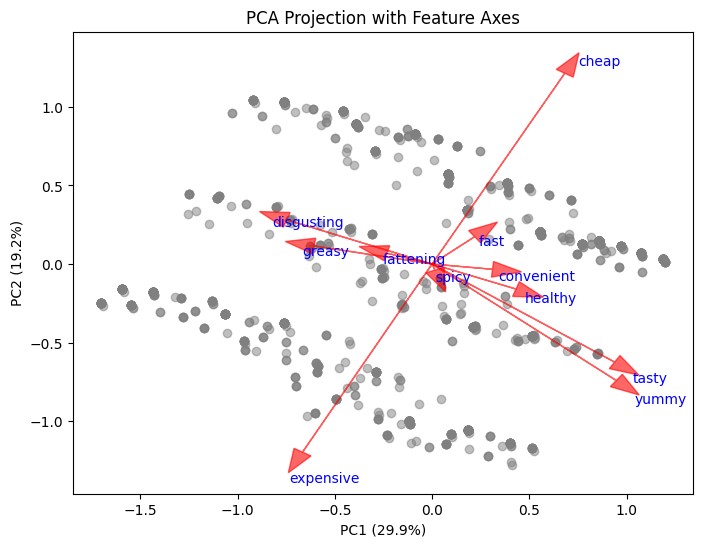

In [318]:
# PCA-transformed data
df_pca = pca.transform(df)

# Plot the PCA data (first 2 components)
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], color='grey', alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title('PCA Projection with Feature Axes')

# Plot projection axes
for i, feature in enumerate(df.columns):
    plt.arrow(0, 0,
              pca.components_[0, i]*2,
              pca.components_[1, i]*2,
              color='red', alpha=0.6, head_width=0.1)
    plt.text(pca.components_[0, i]*2.2,
             pca.components_[1, i]*2.2,
             feature, color='Blue', ha='left', va='top')
plt.show()

In [319]:
# Another method to plot the projection axes
#pip install bioinfokit
#from bioinfokit.visuz import cluster
#cluster.biplot(cscore=df_pca, loadings=-component, labels=df.columns.values,var1=0,var2=0, show=True, dim=(12, 8))

**Extracting Segments (Step 5.1)**

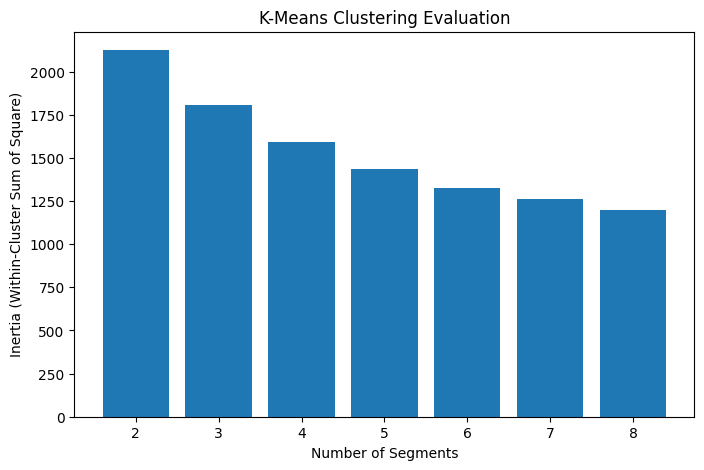

In [320]:
# Store clustering results for k = 2 to 8
km_inertia=[]
kmeans={}

for k in range(2,9):      # k = 2 to 8
  km=KMeans(n_clusters=k, n_init=10, random_state=1234)
  km.fit(df)
  km_inertia.append(km.inertia_)
  kmeans[k] = km

# Plot inertia vs number of clusters
plt.figure(figsize=(8,5))
plt.bar(range(2,9), km_inertia)
plt.xlabel("Number of Segments")
plt.ylabel("Inertia (Within-Cluster Sum of Square)")
plt.title("K-Means Clustering Evaluation")
plt.show()

 The sum of distances within
 market segments drops slowly as the number of market segments increases.

In [321]:
np.random.seed(1234)

nboot = 100
k_range = range(2, 9)
n_init = 10

cluster_stability = {k: [] for k in k_range}

for k in k_range:
    print(f"Bootstrapping for k = {k}")

    # Original model
    original_model = KMeans(n_clusters=k, n_init=n_init, random_state=1234)
    original_labels = original_model.fit_predict(df.values)

    for _ in range(nboot):
        # Bootstrap sampling
        indices = np.random.choice(len(df), size=len(df), replace=True)
        df_x_boot = df.iloc[indices]

        model = KMeans(n_clusters=k, n_init=n_init, random_state=1234)
        labels = model.fit_predict(df_x_boot.values)

        # Compare only overlapping rows
        original_indices = np.unique(indices)
        try:
            common_labels_orig = original_labels[original_indices]
            common_labels_boot = labels[[np.where(indices == idx)[0][0] for idx in original_indices]]
            ari = adjusted_rand_score(common_labels_orig, common_labels_boot)
            cluster_stability[k].append(ari)
        except IndexError:
            continue

# Print stability summary
print("\nAverage Stability (ARI) for each k:")
for k, aris in cluster_stability.items():
    print(f"k = {k}: ARI = {np.mean(aris):.3f}")

Bootstrapping for k = 2
Bootstrapping for k = 3
Bootstrapping for k = 4
Bootstrapping for k = 5
Bootstrapping for k = 6
Bootstrapping for k = 7
Bootstrapping for k = 8

Average Stability (ARI) for each k:
k = 2: ARI = 0.965
k = 3: ARI = 0.927
k = 4: ARI = 0.913
k = 5: ARI = 0.781
k = 6: ARI = 0.766
k = 7: ARI = 0.530
k = 8: ARI = 0.580


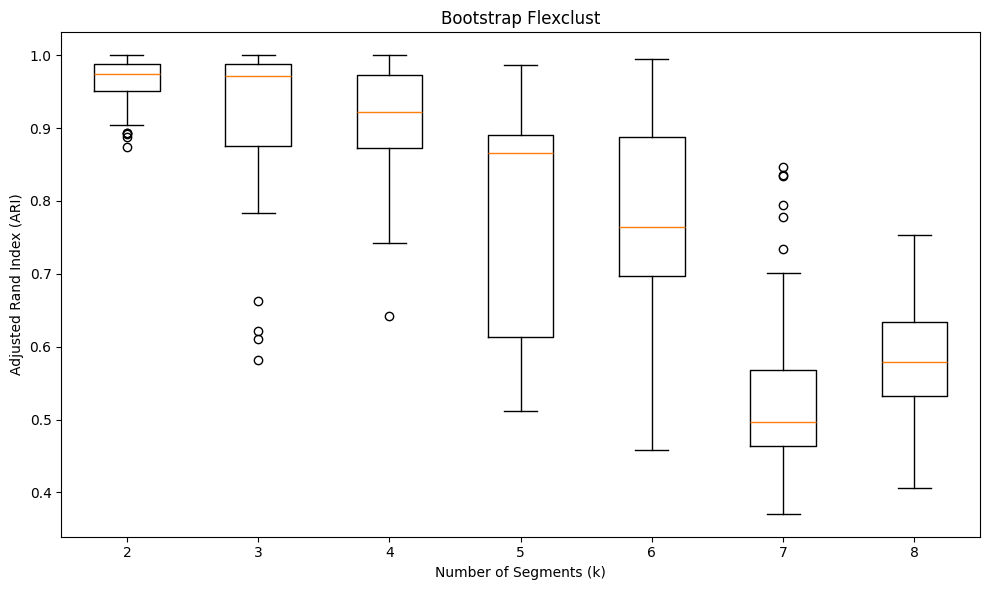

In [322]:
k_vals = list(cluster_stability.keys())
k_vals

# Boxplot of ARI scores for each k
plt.figure(figsize=(10, 6))
plt.boxplot([cluster_stability[i] for i in k_vals],  labels=k_vals)
plt.xlabel("Number of Segments (k)")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.title("Bootstrap Flexclust")
plt.tight_layout()
plt.show()

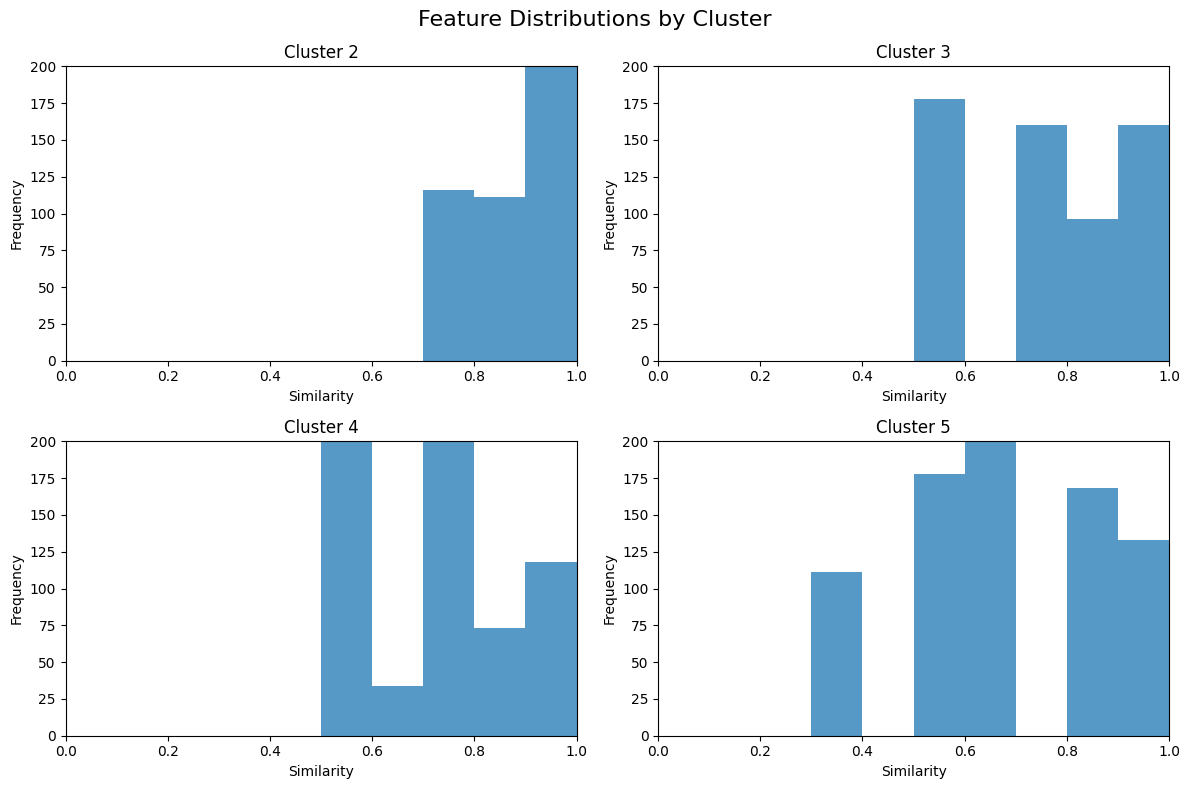

In [323]:
# Prepare 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot histograms for each cluster
for i in range(2,6):
    labels = kmeans[i].predict(df)
    similarities = kmeans[i].transform(df).min(axis=1)

    row = (i - 2) // 2
    col = (i - 2) % 2

    axs[row,col].hist(similarities, bins=10, range=(0, 1), alpha=0.75)
    axs[row,col].set_title(f"Cluster {i}")
    axs[row,col].set_xlabel("Similarity")
    axs[row,col].set_ylabel("Frequency")

    axs[row, col].set_xlim(0,1)
    axs[row, col].set_ylim(0,200)
    axs[row, col].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Final layout and display
fig.suptitle("Feature Distributions by Cluster", fontsize=16)
plt.tight_layout()
plt.show()

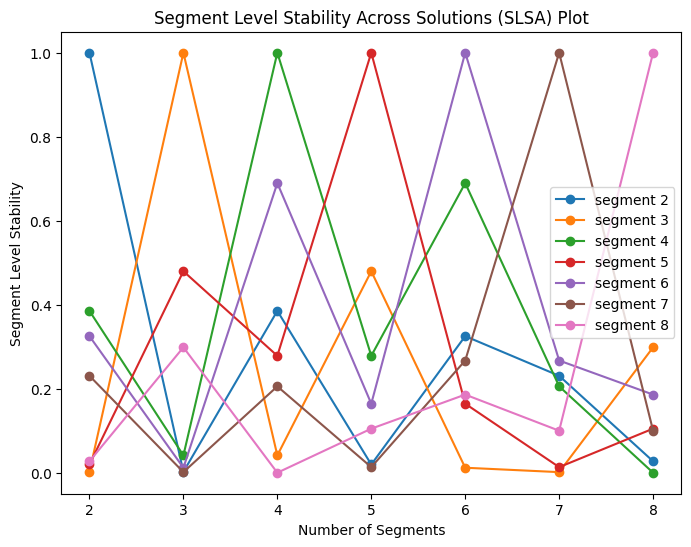

In [324]:
labels=[]

for i in range(2,9):
  labels.append(kmeans[i].predict(df))

plt.figure(figsize=(8,6))
for i, segment in enumerate(range(2,9)):
  plt.plot(range(2,9), [np.mean(labels[i]==k) for k in labels], marker='o', label=f"segment {segment}")

plt.xlabel('Number of Segments')
plt.ylabel('Segment Level Stability')
plt.title('Segment Level Stability Across Solutions (SLSA) Plot')
plt.xticks(range(2,9))
plt.legend()
plt.show()

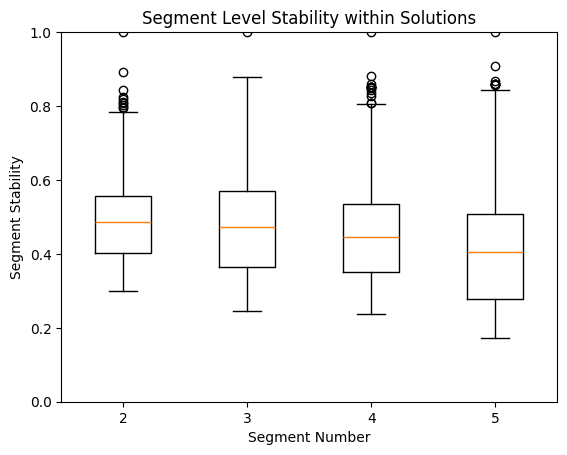

In [325]:
segment_labels = {}
segment_similarities = {}

for i in range(2,6):
    segment_labels[i] = kmeans[i].predict(df)
    segment_similarities[i] = kmeans[i].transform(df).min(axis=1)

segment_stability_values = []
for i in range(2,6):
    similarities = segment_similarities[i]
    normalized_similarities = similarities / np.max(similarities)
    segment_stability_values.append(normalized_similarities)

plt.boxplot(segment_stability_values, whis=1.5)
plt.xlabel("Segment Number")
plt.ylabel("Segment Stability")
plt.xticks(range(1, 5), range(2, 6))
plt.ylim(0, 1)
plt.title("Segment Level Stability within Solutions")
plt.show()

**Using Mixtures of Distributions (Step 5.2)**

In [326]:
from scipy.stats import entropy
from sklearn.mixture import GaussianMixture
from patsy import dmatrices, dmatrix
from scipy.cluster.hierarchy import linkage, dendrogram

In [327]:
np.random.seed(1234)
df_km = []

for k in k_vals:
    model = KMeans(n_clusters=k, random_state=1234)
    model.fit(df.values)
    iter_val = model.n_iter_
    converged = True
    k_val = k
    k0_val = k
    log_likelihood = -model.inertia_
    n_samples, _ = df.shape
    aic = -2 * log_likelihood + 2 * k
    bic = -2 * log_likelihood + np.log(n_samples) * k
    labels = model.labels_
    counts = np.bincount(labels)
    probs = counts / float(counts.sum())
    class_entropy = entropy(probs)
    icl = bic - class_entropy

    df_km.append((iter_val, converged, k_val, k0_val, log_likelihood, aic, bic, icl))
df_km = pd.DataFrame(df_km, columns=['iter', 'converged', 'k', 'k0', 'logLik', 'AIC', 'BIC', 'ICL'])

print(df_km)


   iter  converged  k  k0       logLik          AIC          BIC          ICL
0     7       True  2   2 -2124.795438  4253.590876  4264.123134  4263.456328
1     7       True  3   3 -1917.442295  3840.884589  3856.682976  3855.623077
2     9       True  4   4 -1639.384387  3286.768775  3307.833290  3306.482332
3     6       True  5   5 -1460.841715  2931.683430  2958.014074  2956.466167
4     9       True  6   6 -1324.832078  2661.664156  2693.260928  2691.495671
5     6       True  7   7 -1280.358467  2574.716935  2611.579836  2609.720408
6     6       True  8   8 -1205.606583  2427.213167  2469.342197  2467.317232


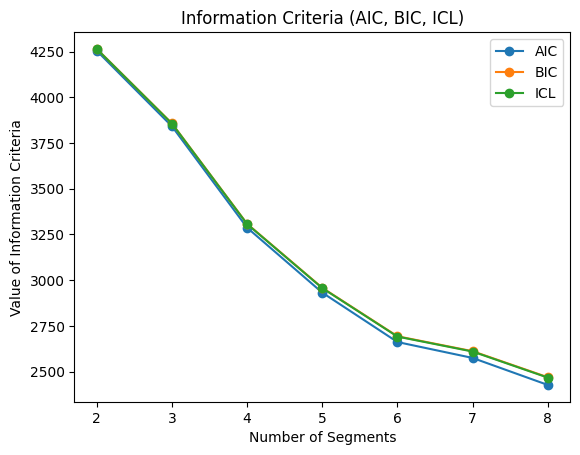

In [328]:
num_segments = df_km["k"]
AIC_values = df_km["AIC"]
BIC_values = df_km["BIC"]
ICL_values = df_km["ICL"]

plt.plot(num_segments, AIC_values, marker='o', label='AIC')
plt.plot(num_segments, BIC_values, marker='o', label='BIC')
plt.plot(num_segments, ICL_values, marker='o', label='ICL')

plt.xlabel('Number of Segments')
plt.ylabel('Value of Information Criteria')
plt.title('Information Criteria (AIC, BIC, ICL)')
plt.legend()
plt.show()

In [329]:
km = KMeans(n_clusters=4, random_state=1234)
km.fit(df)
km_clusters = km.predict(df)

gmm = GaussianMixture(n_components=4, random_state=1234)
gmm.fit(df)
gmm_clusters = gmm.predict(df)

results = pd.DataFrame({'kmeans': km_clusters, 'mixture': gmm_clusters})
print(pd.crosstab(results['kmeans'], results['mixture']))

log_likelihood_gmm = gmm.score(df)
print("Log-likelihood for MD.m4a:", log_likelihood_gmm)

mixture    0    1    2    3
kmeans                     
0        284    4   18  206
1          7  248   32   34
2         15    4  228    0
3         17   11    0  323
Log-likelihood for MD.m4a: 10.447412725165467


In [330]:
# Define a mapping of string values to numeric codes
like_mapping = {
    'I hate it!-5': -5,
    '-4': -4,
    '-3': -3,
    '-2': -2,
    '-1': -1,
    '0': 0,
    '+1': 1,
    '+2': 2,
    '+3': 3,
    '+4': 4,
    'I love it!+5': 5
}

data['Like'] = data['Like'].map(like_mapping)
like_counts = data['Like'].value_counts()
like_counts

,count
Like,
3,225
2,180
0,168
4,156
1,152
-5,150
5,140
-3,73
-4,70


In [331]:
df_copy=df.copy()

formula_str = ' + '.join(df_copy)
formula_str = 'Like ~ ' + formula_str

f = dmatrices(formula_str, data=data)[1]
print(f)

[[1. 0. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 1. 0. 0.]
 [1. 0. 1. ... 1. 1. 0.]
 ...
 [1. 1. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 1. 0. 1.]]


In [332]:
np.random.seed(1234)

X = dmatrix(f.design_info, data=data)
y = dmatrix('Like', data=data)

model = GaussianMixture(n_components=2, n_init=10, verbose=False)
df_reg = model.fit(X, y)

print(df_reg)
cluster_sizes = np.bincount(model.predict(X))

print("Cluster sizes:")
for i, size in enumerate(cluster_sizes):
    print(f"{i+1}: {size}")

GaussianMixture(n_components=2, n_init=10, verbose=False)
Cluster sizes:
1: 966
2: 465


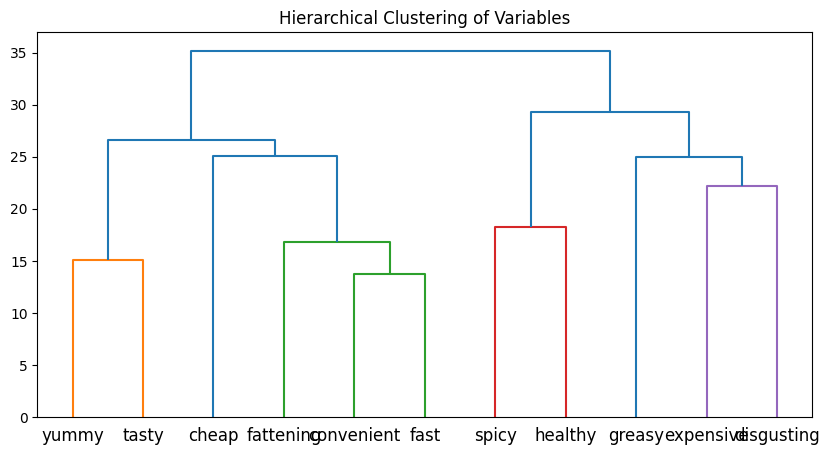

In [333]:
MD_vclust = linkage(df.T, method='complete')
plt.figure(figsize=(10,5))
dendrogram(MD_vclust, labels=df.columns)
plt.title('Hierarchical Clustering of Variables')
plt.show()

**Profiling Segment (Step 6)**

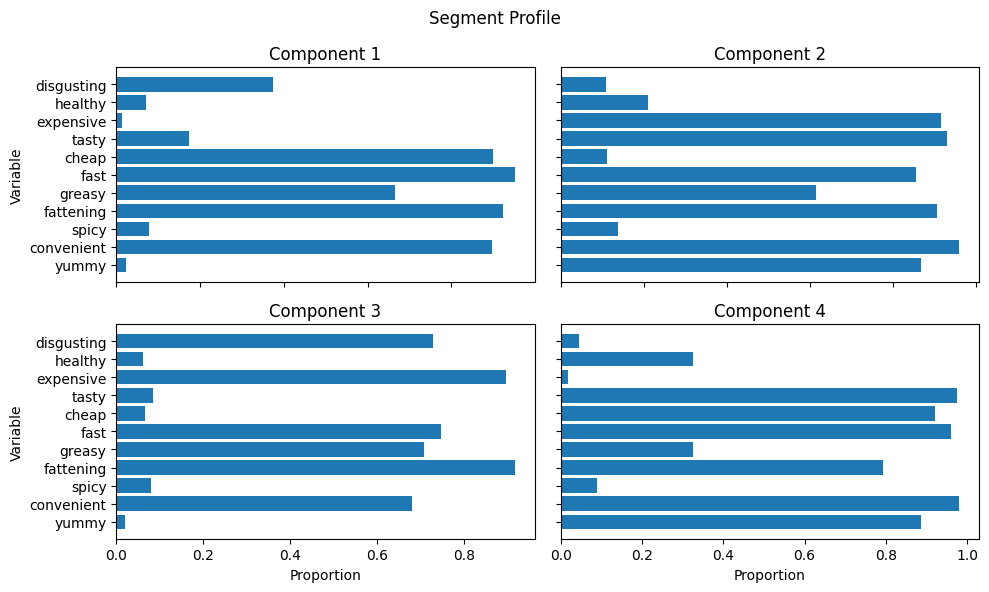

In [334]:
km = kmeans[4]
labels = km.labels_
df_mean=df.groupby(labels).mean()

fig, axs = plt.subplots(2,2,figsize=(10,6))

for i in range(1,5):
    row = (i - 1) // 2
    col = (i - 1) % 2
    axs[row,col].barh(range(df_mean.shape[1]),df_mean.iloc[i-1])
    axs[row,col].set_title(f'Component {i}')

for ax in axs.flat:
    ax.set(ylabel='Variable', xlabel='Proportion')
    ax.set_yticks(range(df_mean.shape[1]))
    ax.set_yticklabels(df.columns)
    ax.label_outer()

fig.suptitle("Segment Profile")
fig.tight_layout()
fig.show()

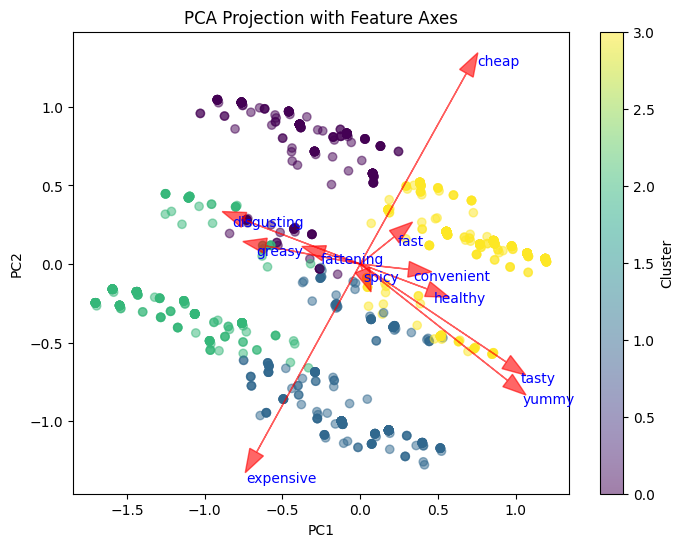

In [335]:
df_km=km.transform(df)

# PCA-transformed data
pca=PCA(n_components=2)
df_pca = pca.fit(df).transform(df)

# Plot the PCA data
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1],c=labels, cmap='viridis', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection with Feature Axes')
plt.colorbar(label='Cluster')

# Plot projection axes
for i, feature in enumerate(df.columns):
    plt.arrow(0, 0,
              pca.components_[0, i]*2,
              pca.components_[1, i]*2,
              color='red', alpha=0.6, head_width=0.1)
    plt.text(pca.components_[0, i]*2.2,
             pca.components_[1, i]*2.2,
             feature, color='Blue', ha='left', va='top')
plt.show()

**Describing Segments (Step 7)**

In [336]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from statsmodels.graphics.mosaicplot import mosaic

<Figure size 1200x600 with 0 Axes>

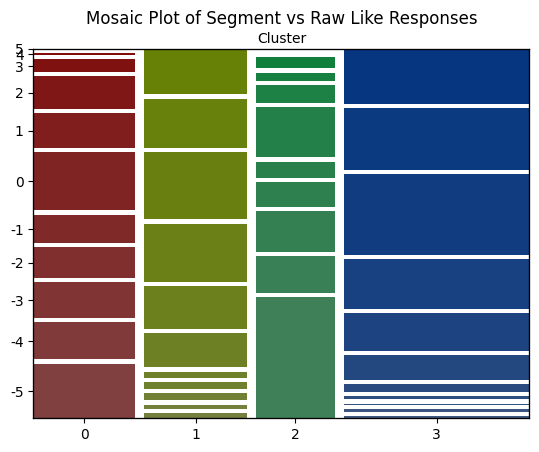

In [337]:
# Create a contingency table
ct = pd.crosstab(labels, data['Like'])

# Convert to stacked Series (required format for mosaic)
ct_stack = ct.stack()

# Create mosaic plot
plt.figure(figsize=(12, 6))
mosaic(ct_stack, gap=0.02, labelizer=lambda k: "")
plt.title('Mosaic Plot of Segment vs Raw Like Responses')
plt.xlabel('Cluster')
plt.ylabel('Like Response')
plt.show()

<Figure size 1200x600 with 0 Axes>

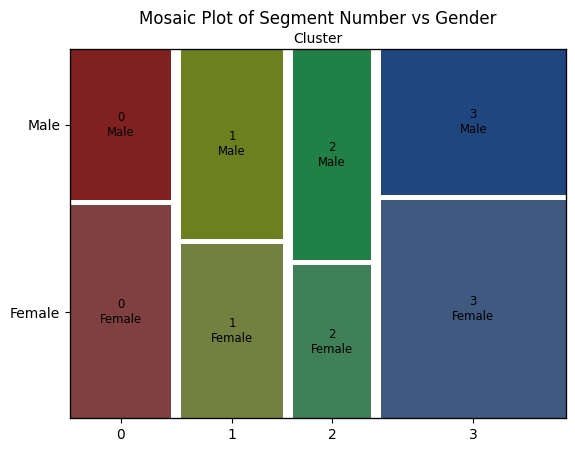

In [338]:
# Crosstab for cluster vs Gender
ct_gender = pd.crosstab(labels, data['Gender'])

# Convert to stacked Series (required format for mosaic)
ct_gender = ct_gender.stack()

# Create mosaic plot without internal labels
plt.figure(figsize=(12, 6))
mosaic(ct_gender, gap=0.02)
plt.xlabel("Cluster")
plt.ylabel("Gender")
plt.title("Mosaic Plot of Segment Number vs Gender")
plt.show()

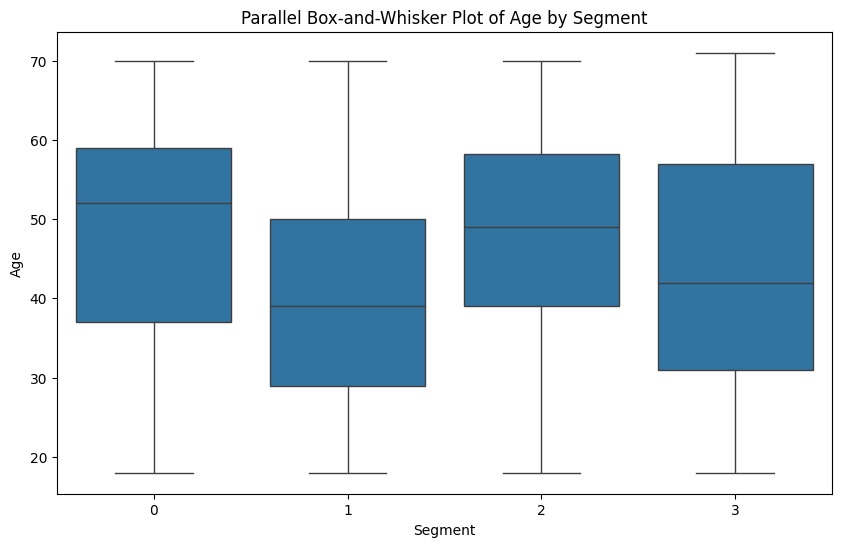

In [339]:
temp_df= pd.DataFrame({'segment': labels, 'age': data['Age']})

# Create a parallel box-and-whisker plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='segment', y='age', data=temp_df)
plt.title('Parallel Box-and-Whisker Plot of Age by Segment')
plt.xlabel('Segment')
plt.ylabel('Age')
plt.show()

**Selecting the Target Segments (Step 8)**

In [340]:
df['VisitFrequency'] = OrdinalEncoder().fit_transform(data['VisitFrequency'].values.reshape(-1, 1))
df['Like'] = LabelEncoder().fit_transform(data['Like'])
df['Gender'] = LabelEncoder().fit_transform(data['Gender'])
df['Age']=data['Age']
df['labels'] = labels

In [341]:
# Group by labels and calculate mean of VisitFrequency, Like.n, and Gender
visit = df.groupby('labels')['VisitFrequency'].mean().to_frame().reset_index()
like = df.groupby('labels')['Like'].mean().to_frame().reset_index()
gender = df.groupby('labels')['Gender'].mean().to_frame().reset_index()

segment = gender.merge(like, on='labels', how='left').merge(visit, on='labels', how='left')
segment

,labels,Gender,Like,VisitFrequency
0,0,0.416129,3.554839,2.812903
1,1,0.522293,7.152866,2.550955
2,2,0.579167,2.325000,2.679167
3,3,0.400353,7.645503,2.578483


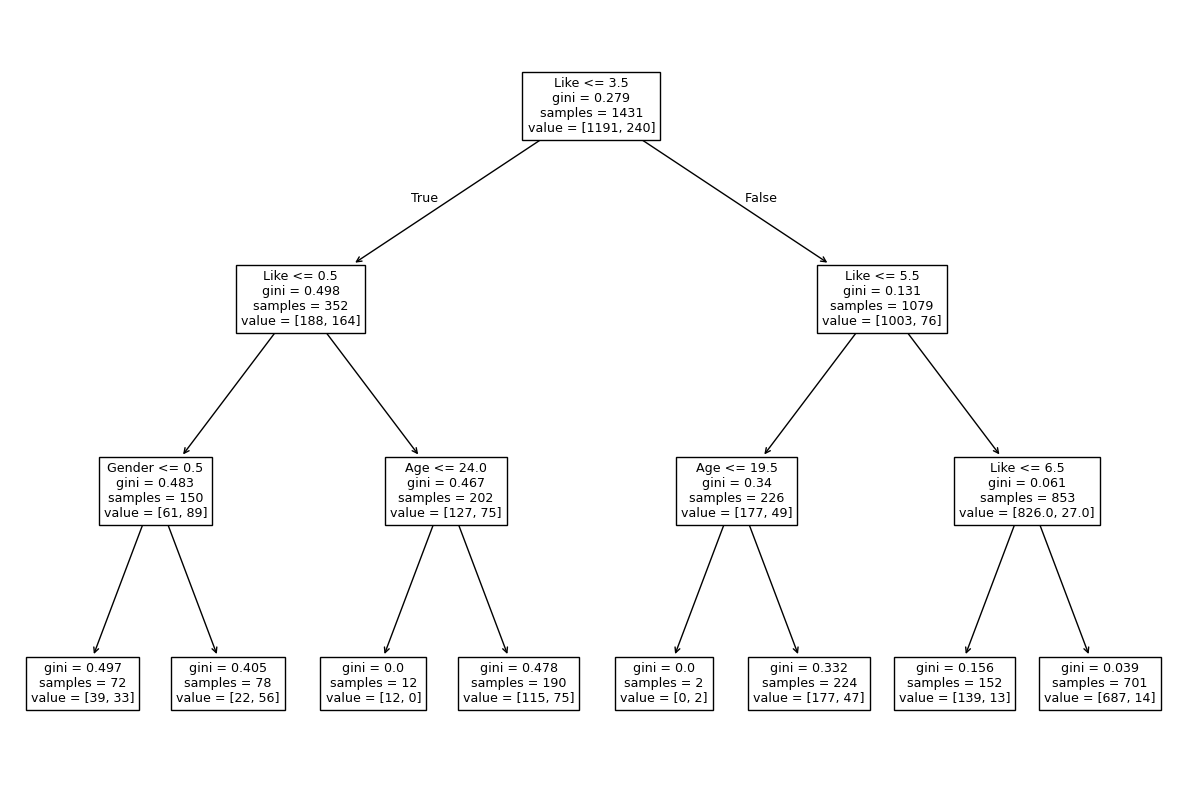

In [342]:
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(df[['Like', 'Age', 'VisitFrequency', 'Gender']],
         labels == 2)

plt.figure(figsize=(15,10))
plot_tree(tree, feature_names=['Like', 'Age', 'VisitFrequency', 'Gender'])
plt.show()

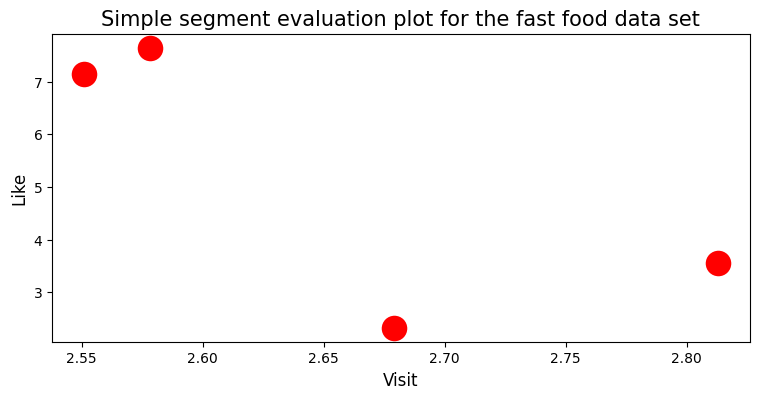

In [343]:
plt.figure(figsize = (9,4))
sns.scatterplot(x="VisitFrequency", y = "Like",data=segment, s=400, color="r")
plt.title("Simple segment evaluation plot for the fast food data set",fontsize = 15)
plt.xlabel("Visit", fontsize = 12)
plt.ylabel("Like", fontsize = 12)
plt.show()